In [1]:
%%capture
%pip -q install wotan transitleastsquares

In [2]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

from IPython.display import clear_output

import json
import yaml

import copy
import os
import subprocess
import sys
import time

import tempfile
import h5py

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import h5py

from wotan import flatten

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['olivedrab', 'steelblue', 'firebrick', 'goldenrod'])
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.limits'] = (0, 0)
plt.rcParams['figure.figsize'] = [6,4]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [3]:
import h5py

# Open the HDF5 file
file_path = 'PSLS/data/trainPlanet.hdf5'
f = h5py.File(file_path, 'r')

# View root-level keys
print(list(f.keys()))

['run_00003', 'run_00006', 'run_00007', 'run_00008', 'run_00009', 'run_00011', 'run_00016', 'run_00017', 'run_00021', 'run_00023', 'run_00026', 'run_00029', 'run_00030', 'run_00031', 'run_00035', 'run_00039', 'run_00042', 'run_00043', 'run_00047', 'run_00055', 'run_00057', 'run_00059', 'run_00060', 'run_00061', 'run_00062', 'run_00063', 'run_00074', 'run_00075', 'run_00077', 'run_00080', 'run_00082', 'run_00086', 'run_00088', 'run_00090', 'run_00091', 'run_00093', 'run_00105', 'run_00107', 'run_00109', 'run_00112', 'run_00115', 'run_00117', 'run_00118', 'run_00119', 'run_00120', 'run_00125', 'run_00129', 'run_00132', 'run_00133', 'run_00138', 'run_00148', 'run_00152', 'run_00156', 'run_00158', 'run_00160', 'run_00164', 'run_00169', 'run_00170', 'run_00171', 'run_00176', 'run_00181', 'run_00182', 'run_00184', 'run_00187', 'run_00188', 'run_00191', 'run_00193', 'run_00195', 'run_00197', 'run_00207', 'run_00213', 'run_00215', 'run_00216', 'run_00217', 'run_00219', 'run_00224', 'run_00226'

Total processed shape: (399552,)
Number of valid numbers in trend: 396419


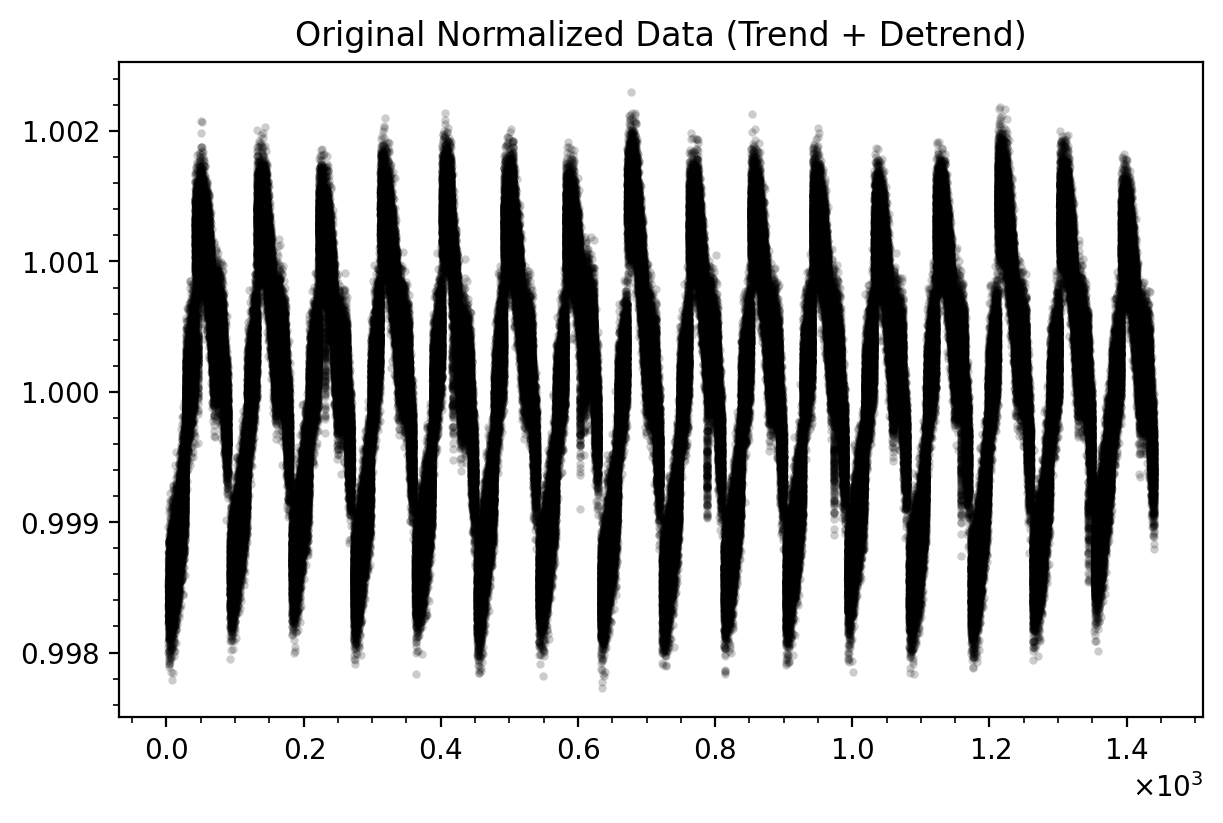

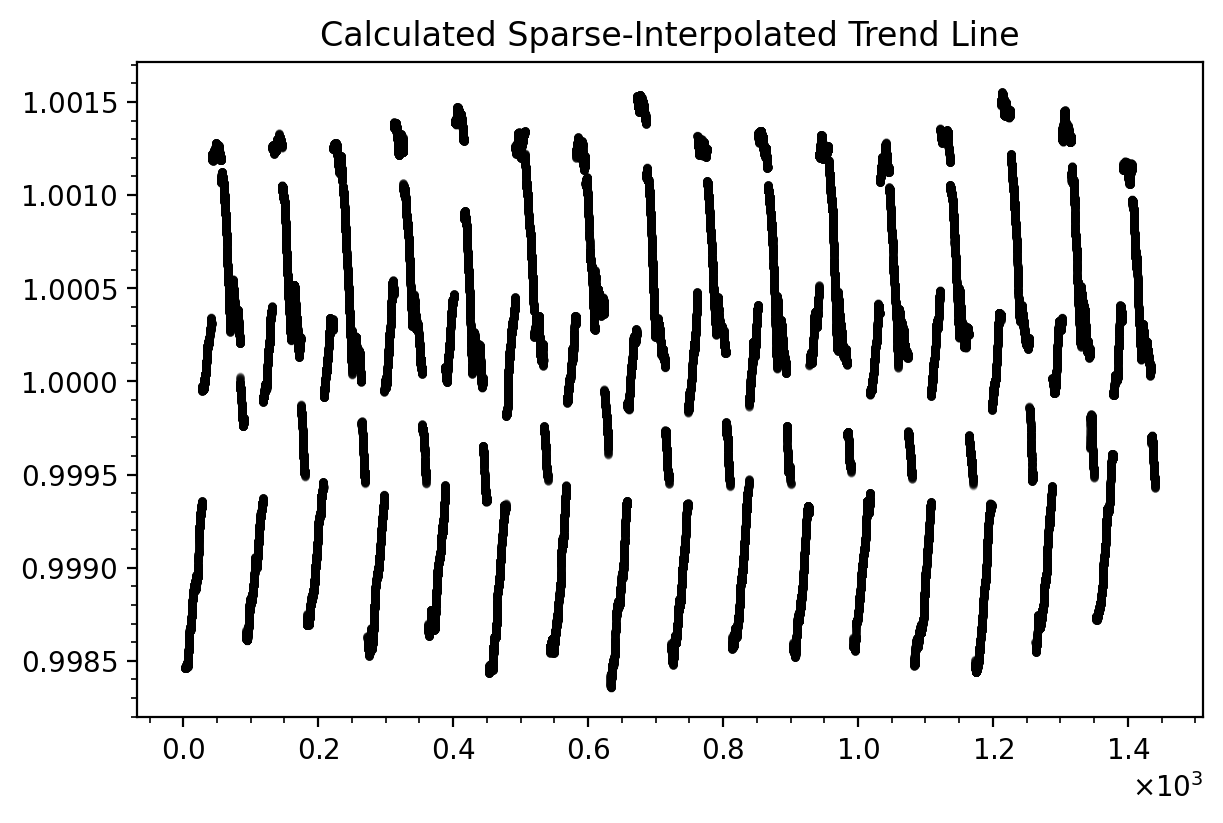

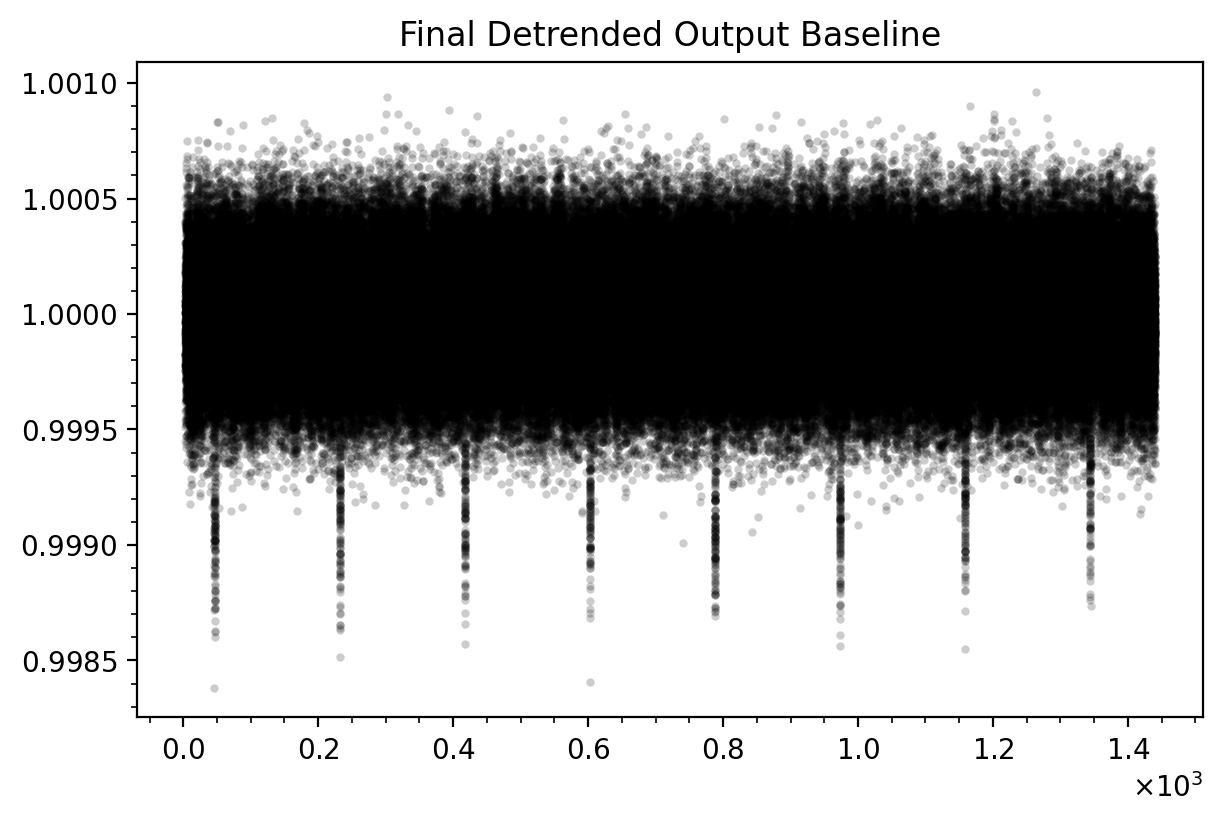

In [22]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from wotan import flatten

index = '00903'

# Open file and extract arrays
# (Assuming 'f' is your open h5py file object)
flag = f[f'run_{index}/dat/flag'][:]
flux = f[f'run_{index}/dat/flux_var_ppm'][:]
time = f[f'run_{index}/dat/time_s'][:] / (60 * 60 * 24)

# -------------------------------------------------------------------------
# FIX 1: Convert 0-centered ppm variation to a normalized baseline of 1.0
# -------------------------------------------------------------------------
flux_norm = 1.0 + (flux / 1e6)

# -------------------------------------------------------------------------
# FIX 2: Find contiguous blocks of data using array transitions
# -------------------------------------------------------------------------
good_mask = (flag == 0.0)
transitions = np.where(np.diff(good_mask.astype(int)) != 0)[0] + 1
split_indices = np.concatenate(([0], transitions, [len(time)]))

WINDOW = 3.0
EDGE = 1/24
STRIDE = 20  # <--- OPTIMIZATION: Process every 20th point for the biweight trend

detrend_chunks = []
trend_chunks = []

# Loop over the actual blocks (both good blocks and bad blocks)
for lo, hi in zip(split_indices[:-1], split_indices[1:]):
    
    # If this segment is a flagged/bad block, do not run wotan.
    if not good_mask[lo]:
        detrend_chunks.append(np.array([np.nan] * (hi - lo)))
        trend_chunks.append(np.array([np.nan] * (hi - lo)))
        continue
        
    # Isolate the clean, unflagged chunk of data
    t_chunk = time[lo:hi]
    f_chunk = flux_norm[lo:hi]
    
    chunk_duration = t_chunk[-1] - t_chunk[0]
    
    # ---------------------------------------------------------------------
    # FIX 3: Dynamic Parameter Protection
    # ---------------------------------------------------------------------
    current_edge = EDGE if chunk_duration > (2 * EDGE) else 0.0
    current_window = WINDOW if chunk_duration > WINDOW else (chunk_duration / 2.0)
    if current_window < 0.1: 
        current_window = 0.1
    
    # ---------------------------------------------------------------------
    # STRIDE OPTIMIZATION: Run Biweight on a Sparse Grid & Interpolate
    # ---------------------------------------------------------------------
    if len(t_chunk) > (STRIDE * 2):
        # 1. Downsample the chunk
        t_sparse = t_chunk[::STRIDE]
        f_sparse = f_chunk[::STRIDE]
        
        # Append the absolute final index if the stride calculation cut it off
        # This protects the chunk boundaries from extrapolation errors
        if (len(t_chunk) - 1) % STRIDE != 0:
            t_sparse = np.append(t_sparse, t_chunk[-1])
            f_sparse = np.append(f_sparse, f_chunk[-1])
            
        # 2. Run wotan exclusively on the tiny sparse subset
        _, tmp_tr_sparse = flatten(
            time=t_sparse,
            flux=f_sparse,
            method='biweight',
            window_length=current_window,
            edge_cutoff=current_edge,
            return_trend=True
        )
        
        # 3. Handle interpolation while preserving the NaN edge_cutoff mask
        good_trend_mask = np.isfinite(tmp_tr_sparse)
        
        if np.any(good_trend_mask):
            valid_times = t_sparse[good_trend_mask]
            t_start, t_end = valid_times[0], valid_times[-1]
            
            # Map sparse trend values back to high resolution
            tmp_tr = np.interp(t_chunk, t_sparse[good_trend_mask], tmp_tr_sparse[good_trend_mask])
            
            # Reinforce NaNs at the edges to perfectly preserve edge_cutoff behavior
            tmp_tr[(t_chunk < t_start) | (t_chunk > t_end)] = np.nan
        else:
            tmp_tr = np.full_like(t_chunk, np.nan)
            
        # Generate the high-resolution detrended chunk
        tmp_detr = f_chunk / tmp_tr

    else:
        # Fallback for ultra-short blocks where striding provides no benefit
        tmp_detr, tmp_tr = flatten(
            time=t_chunk,
            flux=f_chunk,
            method='biweight',
            window_length=current_window,
            edge_cutoff=current_edge,
            return_trend=True
        )
    
    detrend_chunks.append(tmp_detr)
    trend_chunks.append(tmp_tr)

# -------------------------------------------------------------------------
# FIX 4: Reassemble the full dataset smoothly using concatenate
# -------------------------------------------------------------------------
detrend = np.concatenate(detrend_chunks)
trend = np.concatenate(trend_chunks)

# Print verification to confirm everything works!
print(f"Total processed shape: {trend.shape}")
print(f"Number of valid numbers in trend: {np.count_nonzero(~np.isnan(trend))}")

# -------------------------------------------------------------------------
# Diagnostic Plots
# -------------------------------------------------------------------------
plt.plot(time, trend + detrend - 1.0, 'k.', mec='none', alpha=0.2)
plt.title("Original Normalized Data (Trend + Detrend)")
plt.show()

plt.plot(time, trend, 'k.', mec='none', alpha=0.2)
plt.title("Calculated Sparse-Interpolated Trend Line")
plt.show()

plt.plot(time, detrend, 'k.', mec='none', alpha=0.2)
plt.title("Final Detrended Output Baseline")
plt.show()

/tmp/ipykernel_93409/739468795.py:19: RuntimeWarning: invalid value encountered in divide
  binned_flux = (bin_flux / bin_counts)[valid_bins]



--- Wide-Range Safe BLS Search Completed ---
Top Period Candidate:  185.43804 days
Best Epoch T0:         46.32969 days
Transit Duration:      12.00 hours (0.50000 days)
Transit Depth:         710.4 ppm (0.00071 fractional)
Max BLS Power:         0.00
Signal-to-Noise Ratio: 0.01
Actual Seen Transits:  8 (out of 8 theoretical)


/tmp/ipykernel_93409/739468795.py:89: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


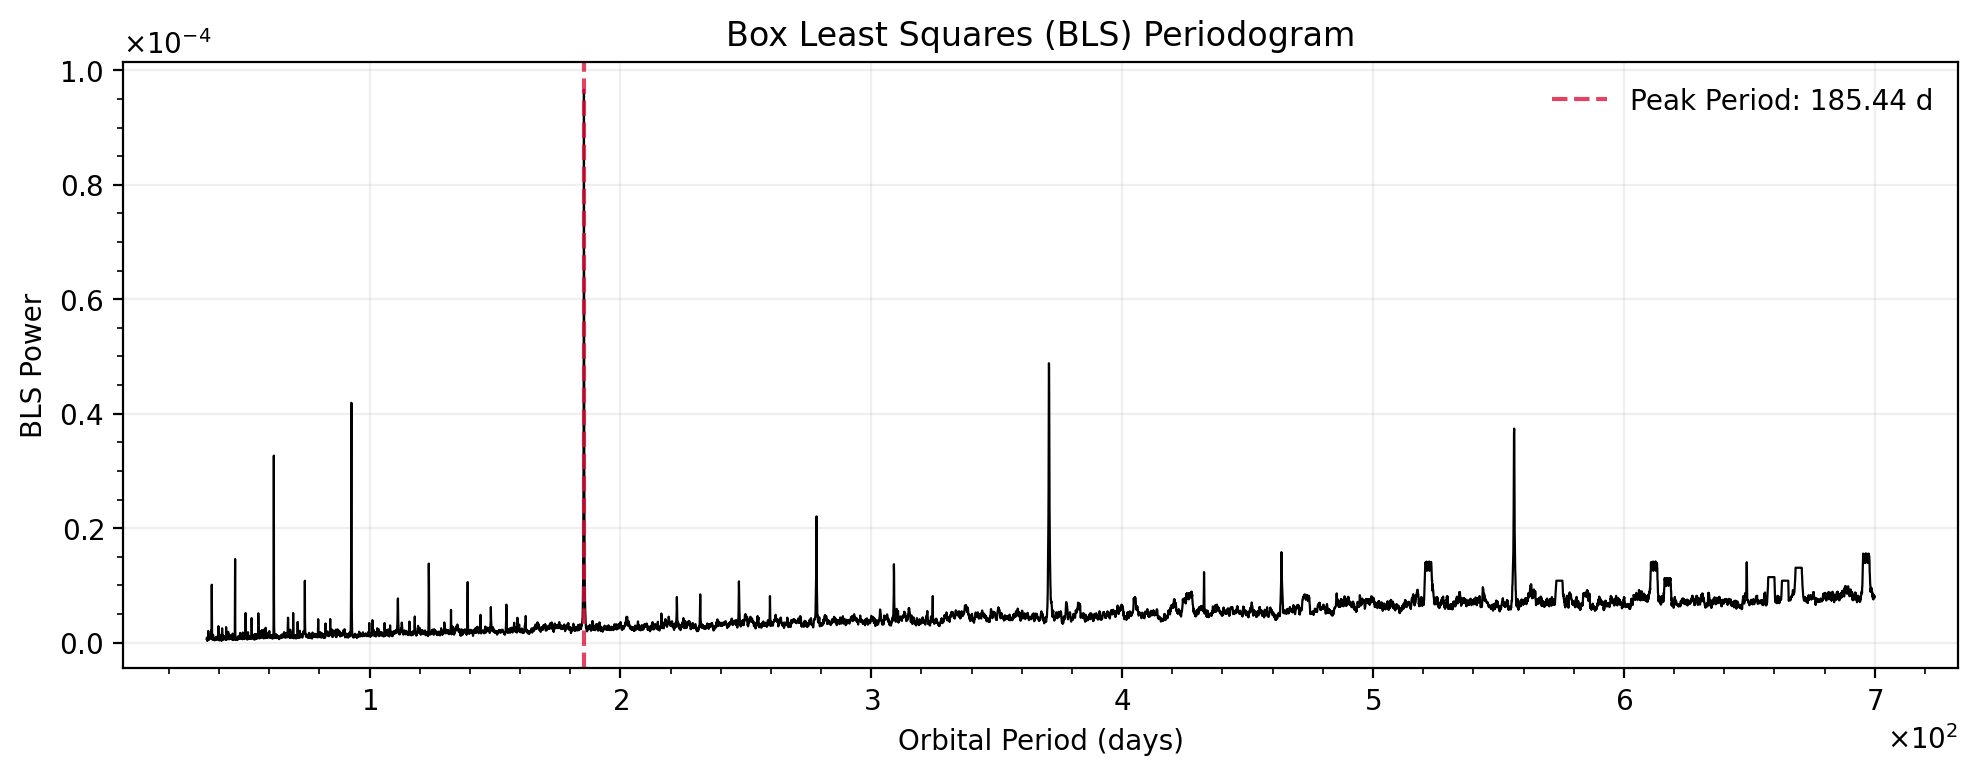

/tmp/ipykernel_93409/739468795.py:117: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


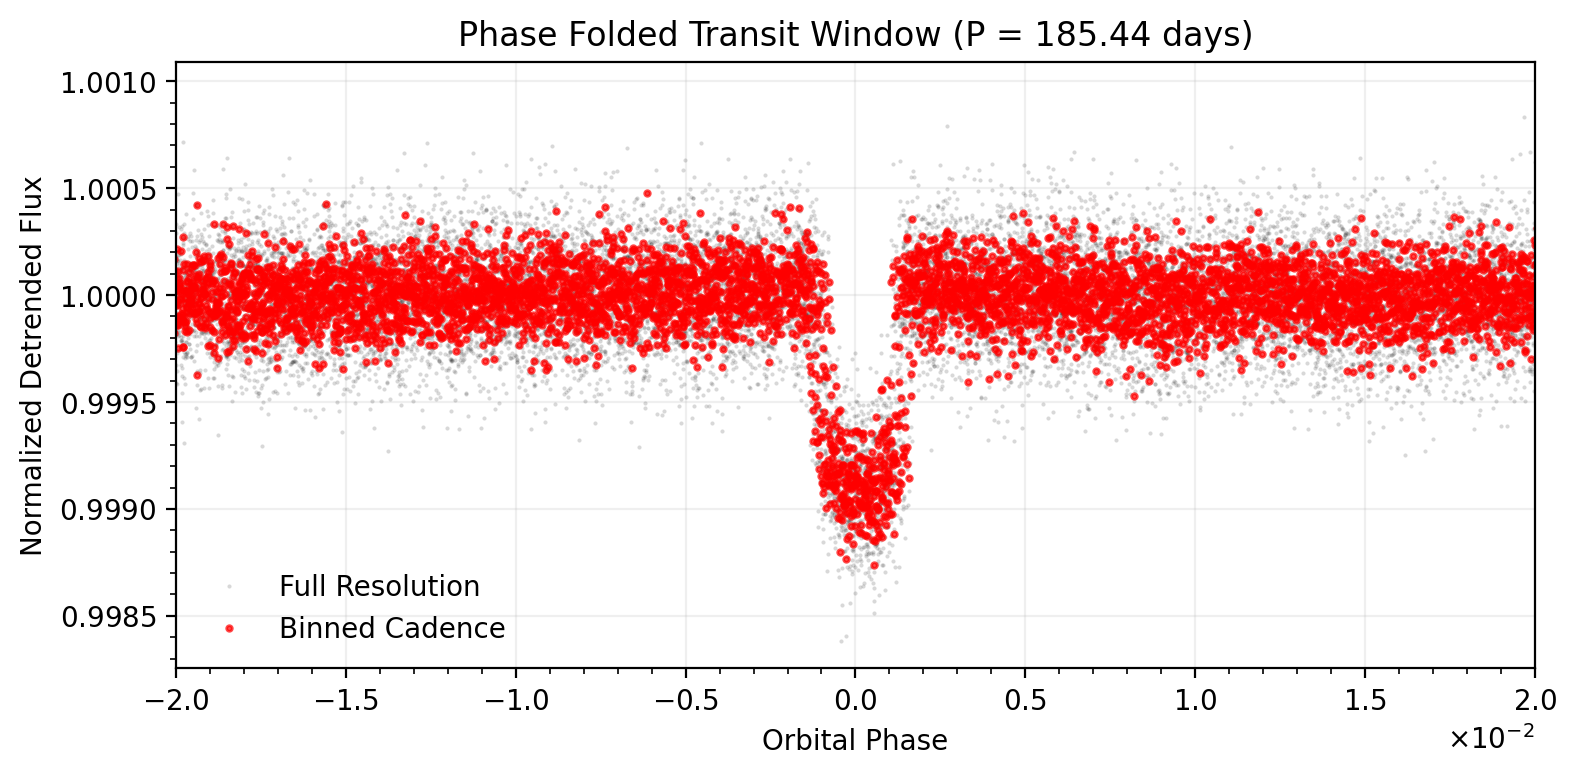

In [18]:
# ... [Your existing code ends here with detrend and trend reassembled] ...

# -------------------------------------------------------------------------
# STEP 1: Fast Binning (2-Hour Cadence: Balanced for 10 to 700 Days)
# -------------------------------------------------------------------------
clean_mask = np.isfinite(time) & np.isfinite(detrend)
tls_time_raw = time[clean_mask]
tls_flux_raw = detrend[clean_mask]

# 2 hours = 2.0 / 24.0 days
bin_size = 0.25 / 24.0 
bin_edges = np.arange(tls_time_raw[0], tls_time_raw[-1] + bin_size, bin_size)

bin_counts, _ = np.histogram(tls_time_raw, bins=bin_edges)
bin_flux, _ = np.histogram(tls_time_raw, bins=bin_edges, weights=tls_flux_raw)

valid_bins = bin_counts > 0
binned_time = (bin_edges[:-1] + bin_size / 2.0)[valid_bins]
binned_flux = (bin_flux / bin_counts)[valid_bins]

# -------------------------------------------------------------------------
# STEP 2: Define a Safe, Explicit Period Array (Prevents OOM Crashes)
# -------------------------------------------------------------------------
# We hand-craft a grid of 10,000 points. This covers the 10-700 day range 
# beautifully without ever ballooning your laptop's memory.
explicit_periods = np.linspace(35.0, 700.0, 10000)

# Define 5 distinct physical transit durations to check (from 3 to 36 hours)
trial_durations = np.linspace(3.0 / 24.0, 36.0 / 24.0, 5)

# -------------------------------------------------------------------------
# STEP 3: Run BLS via .power() instead of .autopower()
# -------------------------------------------------------------------------
from astropy.timeseries import BoxLeastSquares

model = BoxLeastSquares(binned_time, binned_flux)

# We pass our explicit array and set oversample=1 to prevent internal phase multiplying
results = model.power(
    period=explicit_periods, 
    duration=trial_durations,
    oversample=1 
)

# -------------------------------------------------------------------------
# STEP 4: Extract Winning Parameters & Advanced Stats (Crash-Safe)
# -------------------------------------------------------------------------
max_idx = np.argmax(results.power)
best_period = results.period[max_idx]
best_t0 = results.transit_time[max_idx]

# Pull the precise duration and depth matched at the peak power index
best_duration = results.duration[max_idx]
best_depth = results.depth[max_idx] 

# Calculate native deep-dive validation metrics
stats = model.compute_stats(best_period, best_duration, best_t0)

# Calculate SNR directly from the depth + depth_error tuple
depth_val, depth_err = stats['depth']
calculated_snr = depth_val / depth_err

# Count transits that actually contain data points
actual_transit_count = np.sum(stats['per_transit_count'] > 0)

print(f"\n--- Wide-Range Safe BLS Search Completed ---")
print(f"Top Period Candidate:  {best_period:.5f} days")
print(f"Best Epoch T0:         {best_t0:.5f} days")
print(f"Transit Duration:      {best_duration * 24.0:.2f} hours ({best_duration:.5f} days)")
print(f"Transit Depth:         {best_depth * 1e6:.1f} ppm ({best_depth:.5f} fractional)")
print(f"Max BLS Power:         {results.power[max_idx]:.2f}")
print(f"Signal-to-Noise Ratio: {calculated_snr:.2f}")
print(f"Actual Seen Transits:  {actual_transit_count} (out of {len(stats['transit_times'])} theoretical)")

# -------------------------------------------------------------------------
# STEP 5: Plot the Periodogram
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(results.period, results.power, color='black', lw=0.8)
plt.axvline(best_period, color='crimson', linestyle='--', alpha=0.8, 
            label=f'Peak Period: {best_period:.2f} d')
plt.title("Box Least Squares (BLS) Periodogram")
plt.xlabel("Orbital Period (days)")
plt.ylabel("BLS Power")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# STEP 6: Phase-Fold & Plot the Light Curve Window
# -------------------------------------------------------------------------
# Using 'tls_time_raw' and 'tls_flux_raw' to view the true unbinned dip
phase = ((tls_time_raw - best_t0) % best_period) / best_period

# Shift phases to center the transit profile perfectly at 0.0
phase[phase > 0.5] -= 1.0

plt.figure(figsize=(8, 4))
# Plot raw high-res measurements in the background
plt.plot(phase, tls_flux_raw, 'k.', markersize=1, alpha=0.15, label='Full Resolution')

# Phase-fold and superimpose the binned points to highlight the box structure
binned_phase = ((binned_time - best_t0) % best_period) / best_period
binned_phase[binned_phase > 0.5] -= 1.0
plt.plot(binned_phase, binned_flux, 'r.', markersize=4, alpha=0.7, label='Binned Cadence')

# Tight zoom around the transit window (-5% to +5% phase width)
plt.xlim(-0.02, 0.02)  
plt.title(f"Phase Folded Transit Window (P = {best_period:.2f} days)")
plt.xlabel("Orbital Phase")
plt.ylabel("Normalized Detrended Flux")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [6]:
datasets = ['trainPlanet', 'trainStar', 'realPlanet', 'realStar']

extract_truth = pd.DataFrame()

for dataset in datasets:
    with h5py.File(f'PSLS/data/{dataset}.hdf5', 'r') as hdf:
        print()

group = f['run_00006']

raw_yaml = group.attrs['config_used']
metadata_dict = yaml.safe_load(raw_yaml)
metadata_dict

{'Observation': {'QuarterDuration': [90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0],
  'MasterSeed': 5,
  'Gaps': {'Enable': 1,
   'Seed': -1,
   'InterQuarterGapDuration': 3.0,
   'RandomGapDuration': 20.0,
   'RandomGapTimeFraction': 0.05,
   'RandomGapStep': 0.0,
   'PeriodicGapCadence': 5.0,
   'PeriodicGapDuration': 20.0,
   'PeriodicGapJitter': 2.0,
   'PeriodicGapStep': 0.0}},
 'Instrument': {'Sampling': 300.0,
  'IntegrationTime': 252.0,
  'GroupID': [1, 2, 3, 4],
  'NCamera': 6,
  'TimeShift': 6.25,
  'RandomNoise': {'Enable': 1, 'Type': 'PLATO_SIMU', 'NSR': 73.0},
  'Systematics': {'Enable': 1,
   'Table': 'systematics/PLATO_systematics_BOL_V2.npy',
   'Version': 2,
   'DriftLevel': 'any',
   'Seed': -1}},
 'Star': {'Mag': 9.570405297778155,
  'ID': 5,
  'ModelType': 'grid',
  'ModelDir': 'models/',
  'ModelName': 'grid.hdf5',
  'ES': 'ms',
  'Teff': 6131.507573344333,
  'Logg': 4.41

In [7]:
import os
import sys
import time
import h5py
import numpy as np
from wotan import flatten
from astropy.timeseries import BoxLeastSquares
from IPython.display import clear_output

# -------------------------------------------------------------------------
# FUNCTION 1: Detrending (Wotan Biweight + Sparse Grid)
# -------------------------------------------------------------------------
def detrend(time, flux, flag):
    # Convert 0-centered ppm variation to a normalized baseline of 1.0
    flux_norm = 1.0 + (flux / 1e6)

    # Find contiguous blocks of data using array transitions
    good_mask = (flag == 0.0)
    transitions = np.where(np.diff(good_mask.astype(int)) != 0)[0] + 1
    split_indices = np.concatenate(([0], transitions, [len(time)]))

    WINDOW = 3.0
    EDGE = 1/24
    STRIDE = 20  # Process every 20th point for the biweight trend

    detrend_chunks = []
    trend_chunks = []

    # Loop over the actual blocks
    for lo, hi in zip(split_indices[:-1], split_indices[1:]):
        
        # If segment is a flagged/bad block, do not run wotan
        if not good_mask[lo]:
            detrend_chunks.append(np.array([np.nan] * (hi - lo)))
            trend_chunks.append(np.array([np.nan] * (hi - lo)))
            continue
            
        t_chunk = time[lo:hi]
        f_chunk = flux_norm[lo:hi]
        chunk_duration = t_chunk[-1] - t_chunk[0]
        
        # Dynamic Parameter Protection
        current_edge = EDGE if chunk_duration > (2 * EDGE) else 0.0
        current_window = WINDOW if chunk_duration > WINDOW else (chunk_duration / 2.0)
        if current_window < 0.1: 
            current_window = 0.1
        
        # STRIDE OPTIMIZATION
        if len(t_chunk) > (STRIDE * 2):
            t_sparse = t_chunk[::STRIDE]
            f_sparse = f_chunk[::STRIDE]
            
            if (len(t_chunk) - 1) % STRIDE != 0:
                t_sparse = np.append(t_sparse, t_chunk[-1])
                f_sparse = np.append(f_sparse, f_chunk[-1])
                
            _, tmp_tr_sparse = flatten(
                time=t_sparse,
                flux=f_sparse,
                method='biweight',
                window_length=current_window,
                edge_cutoff=current_edge,
                return_trend=True
            )
            
            good_trend_mask = np.isfinite(tmp_tr_sparse)
            
            if np.any(good_trend_mask):
                valid_times = t_sparse[good_trend_mask]
                t_start, t_end = valid_times[0], valid_times[-1]
                
                tmp_tr = np.interp(t_chunk, t_sparse[good_trend_mask], tmp_tr_sparse[good_trend_mask])
                tmp_tr[(t_chunk < t_start) | (t_chunk > t_end)] = np.nan
            else:
                tmp_tr = np.full_like(t_chunk, np.nan)
                
            tmp_detr = f_chunk / tmp_tr

        else:
            # Fallback for ultra-short blocks
            tmp_detr, tmp_tr = flatten(
                time=t_chunk,
                flux=f_chunk,
                method='biweight',
                window_length=current_window,
                edge_cutoff=current_edge,
                return_trend=True
            )
        
        detrend_chunks.append(tmp_detr)
        trend_chunks.append(tmp_tr)

    # Reassemble and return
    full_detrend = np.concatenate(detrend_chunks)
    full_trend = np.concatenate(trend_chunks)
    
    return full_trend, full_detrend

# -------------------------------------------------------------------------
# FUNCTION 2: Detection (Astropy BLS)
# -------------------------------------------------------------------------
def detect(time, detrend_data):
    # Strip NaNs
    clean_mask = np.isfinite(time) & np.isfinite(detrend_data)
    tls_time_raw = time[clean_mask]
    tls_flux_raw = detrend_data[clean_mask]

    # Fast Binning (2-Hour Cadence)
    bin_size = 0.25 / 24.0 
    bin_edges = np.arange(tls_time_raw[0], tls_time_raw[-1] + bin_size, bin_size)

    bin_counts, _ = np.histogram(tls_time_raw, bins=bin_edges)
    bin_flux, _ = np.histogram(tls_time_raw, bins=bin_edges, weights=tls_flux_raw)

    valid_bins = bin_counts > 0
    binned_time = (bin_edges[:-1] + bin_size / 2.0)[valid_bins]
    binned_flux = (bin_flux / bin_counts)[valid_bins]

    # Safe, Explicit Period Array (Prevents OOM Crashes)
    explicit_periods = np.linspace(35.0, 700.0, 10000)
    trial_durations = np.linspace(3.0 / 24.0, 36.0 / 24.0, 5)

    # Execute BLS
    model = BoxLeastSquares(binned_time, binned_flux)
    results = model.power(
        period=explicit_periods, 
        duration=trial_durations,
        oversample=1 
    )

    return results.period, results.power

# -------------------------------------------------------------------------
# FUNCTION 3: Main Processing Pipeline
# -------------------------------------------------------------------------
def process(input_files, output_filename):
    """
    Iterates through a list of HDF5 input files, applies detrending and BLS detection 
    to each group, and saves the results into a combined target HDF5 file.
    """
    start_batch = time.time()
    
    # Pre-scan inputs to count total subgroups across all files for the status bar
    total_sims = 0
    file_mapping = {}
    for f_name in input_files:
        with h5py.File(f_name, 'r') as f:
            keys = list(f.keys())
            file_mapping[f_name] = keys
            total_sims += len(keys)

    if total_sims == 0:
        print("No valid groups found in the provided files.")
        return

    # Print Initial Status
    empty_bar = '░' * 50
    initial_status = f'│ progress |{empty_bar}| 0% [running 1/{total_sims}] (00:00:00/--:--:--)          '
    print(f'{initial_status}')

    # Process files
    i = 0
    with h5py.File(output_filename, 'a') as out_f:
        for f_name, group_keys in file_mapping.items():
            with h5py.File(f_name, 'r') as in_f:
                for group_name in group_keys:
                    
                    # Update Visual Status Bar
                    if i > 0:
                        perc = (i / total_sims) * 100
                        bar = '█' * int(perc // 2) + '░' * (50 - int(perc // 2))
                        
                        current_run = time.time()
                        elapsed_batch = current_run - start_batch
                        average_time = elapsed_batch / i
                        estimated_batch = elapsed_batch + (total_sims - i) * average_time
                        
                        elapsed_str = time.strftime('%H:%M:%S', time.gmtime(elapsed_batch))
                        estimated_str = time.strftime('%H:%M:%S', time.gmtime(estimated_batch))
                        
                        status = f'│ progress |{bar}| {perc:.0f}% [running {i + 1}/{total_sims}] ({elapsed_str}/{estimated_str})          '
                        
                        clear_output(wait=True)
                        print(f'{status}')
                    
                    sys.stdout.write(f'└── processing {group_name}          ')
                    sys.stdout.flush()
                    
                    # 1. Extract Data
                    flag = in_f[f'{group_name}/dat/flag'][:]
                    flux = in_f[f'{group_name}/dat/flux_var_ppm'][:]
                    time_data = in_f[f'{group_name}/dat/time_s'][:] / (60 * 60 * 24)

                    sys.stdout.write(f'\r└─┬ processing {group_name}          \n')
                    sys.stdout.write(f'  ├── wotan biweight detrending...          ')
                    sys.stdout.flush()

                    # 2. Detrend
                    trend_arr, detrend_arr = detrend(time_data, flux, flag)

                    sys.stdout.write(f'\r  ├── wotan biweight detrending [done]          \n')
                    sys.stdout.write(f'  └── astropy BLS search...          ')
                    sys.stdout.flush()

                    # 3. Detect
                    bls_period, bls_power = detect(time_data, detrend_arr)

                    # 4. Save to Output
                    if group_name in out_f:
                        # Prevent crash if running multiple passes into the same file
                        del out_f[group_name]
                    
                    out_group = out_f.create_group(group_name)
                    out_group.create_dataset('trend', data=trend_arr)
                    out_group.create_dataset('detrend', data=detrend_arr)
                    out_group.create_dataset('bls_period', data=bls_period)
                    out_group.create_dataset('bls_power', data=bls_power)

                    i += 1

    # Print Final Status
    elapsed_batch = time.time() - start_batch
    elapsed_str = time.strftime('%H:%M:%S', time.gmtime(elapsed_batch))
    full_bar = '█' * 50
    final_status = f'│ progress |{full_bar}| 100% [finished {total_sims}/{total_sims}] ({elapsed_str}/{elapsed_str})          '
    
    clear_output(wait=True)
    print(f'{final_status}')

In [8]:
process(['PSLS/data/realPlanet.hdf5'], 'test.hdf5')

│ progress |████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| 17% [running 26/150] (00:01:37/00:09:46)          
└─┬ processing run_03254          
  ├── wotan biweight detrending...          

ValueError: zero-size array to reduction operation minimum which has no identity

In [19]:
import os
import sys
import time
import h5py
import numpy as np
from wotan import flatten
from astropy.timeseries import BoxLeastSquares
from IPython.display import clear_output

# -------------------------------------------------------------------------
# FUNCTION 1: Detrending (Wotan Biweight + Sparse Grid + Failure Protections)
# -------------------------------------------------------------------------
def detrend(time, flux, flag):
    # Guard against completely empty arrays from failed simulation runs
    if len(time) == 0 or len(flux) == 0 or len(flag) == 0:
        return np.array([]), np.array([])

    # Convert 0-centered ppm variation to a normalized baseline of 1.0
    flux_norm = 1.0 + (flux / 1e6)

    # Find contiguous blocks of data using array transitions
    good_mask = (flag == 0.0)
    transitions = np.where(np.diff(good_mask.astype(int)) != 0)[0] + 1
    split_indices = np.concatenate(([0], transitions, [len(time)]))

    WINDOW = 3.0
    EDGE = 1/24
    STRIDE = 20  # Process every 20th point for the biweight trend

    detrend_chunks = []
    trend_chunks = []

    # Loop over the actual blocks
    for lo, hi in zip(split_indices[:-1], split_indices[1:]):
        # Guard against zero-width slices
        if lo == hi:
            continue
            
        # If segment is a flagged/bad block, do not run wotan
        if not good_mask[lo]:
            detrend_chunks.append(np.array([np.nan] * (hi - lo)))
            trend_chunks.append(np.array([np.nan] * (hi - lo)))
            continue
            
        t_chunk = time[lo:hi]
        f_chunk = flux_norm[lo:hi]
        
        # Additional validation check for degraded chunk structures
        if len(t_chunk) == 0:
            continue
            
        chunk_duration = t_chunk[-1] - t_chunk[0]
        
        # Dynamic Parameter Protection
        current_edge = EDGE if chunk_duration > (2 * EDGE) else 0.0
        current_window = WINDOW if chunk_duration > WINDOW else (chunk_duration / 2.0)
        if current_window < 0.1: 
            current_window = 0.1
        
        try:
            # STRIDE OPTIMIZATION
            if len(t_chunk) > (STRIDE * 2):
                t_sparse = t_chunk[::STRIDE]
                f_sparse = f_chunk[::STRIDE]
                
                if (len(t_chunk) - 1) % STRIDE != 0:
                    t_sparse = np.append(t_sparse, t_chunk[-1])
                    f_sparse = np.append(f_sparse, f_chunk[-1])
                    
                _, tmp_tr_sparse = flatten(
                    time=t_sparse,
                    flux=f_sparse,
                    method='biweight',
                    window_length=current_window,
                    edge_cutoff=current_edge,
                    return_trend=True
                )
                
                good_trend_mask = np.isfinite(tmp_tr_sparse)
                
                if np.any(good_trend_mask):
                    valid_times = t_sparse[good_trend_mask]
                    t_start, t_end = valid_times[0], valid_times[-1]
                    
                    tmp_tr = np.interp(t_chunk, t_sparse[good_trend_mask], tmp_tr_sparse[good_trend_mask])
                    tmp_tr[(t_chunk < t_start) | (t_chunk > t_end)] = np.nan
                else:
                    tmp_tr = np.full_like(t_chunk, np.nan)
                    
                tmp_detr = f_chunk / tmp_tr

            else:
                # Fallback for ultra-short blocks
                tmp_detr, tmp_tr = flatten(
                    time=t_chunk,
                    flux=f_chunk,
                    method='biweight',
                    window_length=current_window,
                    edge_cutoff=current_edge,
                    return_trend=True
                )
        except Exception:
            # Catch-all safety net: If Wotan or Numba throws a reduction error 
            # due to bad data shapes, fill the chunk with NaNs to protect execution flow
            tmp_tr = np.full_like(t_chunk, np.nan)
            tmp_detr = np.full_like(t_chunk, np.nan)
        
        detrend_chunks.append(tmp_detr)
        trend_chunks.append(tmp_tr)

    # Reassemble and return safely
    full_detrend = np.concatenate(detrend_chunks) if detrend_chunks else np.array([])
    full_trend = np.concatenate(trend_chunks) if trend_chunks else np.array([])
    
    return full_trend, full_detrend

# -------------------------------------------------------------------------
# FUNCTION 2: Detection (Astropy BLS + Crash Protections)
# -------------------------------------------------------------------------
def detect(time, detrend_data):
    if len(time) == 0 or len(detrend_data) == 0:
        return np.array([]), np.array([])

    # Strip NaNs
    clean_mask = np.isfinite(time) & np.isfinite(detrend_data)
    if np.sum(clean_mask) < 2:
        return np.array([]), np.array([])

    tls_time_raw = time[clean_mask]
    tls_flux_raw = detrend_data[clean_mask]

    # Guard against invalid time range sequencing
    if tls_time_raw[-1] <= tls_time_raw[0]:
        return np.array([]), np.array([])

    # Fast Binning (2-Hour Cadence)
    bin_size = 0.25 / 24.0 
    bin_edges = np.arange(tls_time_raw[0], tls_time_raw[-1] + bin_size, bin_size)

    if len(bin_edges) < 2:
        return np.array([]), np.array([])

    bin_counts, _ = np.histogram(tls_time_raw, bins=bin_edges)
    bin_flux, _ = np.histogram(tls_time_raw, bins=bin_edges, weights=tls_flux_raw)

    valid_bins = bin_counts > 0
    if not np.any(valid_bins):
        return np.array([]), np.array([])

    binned_time = (bin_edges[:-1] + bin_size / 2.0)[valid_bins]
    binned_flux = (bin_flux / bin_counts)[valid_bins]

    # Safe, Explicit Period Array (Prevents OOM Crashes)
    explicit_periods = np.linspace(35.0, 700.0, 10000)
    trial_durations = np.linspace(3.0 / 24.0, 36.0 / 24.0, 5)

    try:
        # Execute BLS with a safety wrapper
        model = BoxLeastSquares(binned_time, binned_flux)
        results = model.power(
            period=explicit_periods, 
            duration=trial_durations,
            oversample=1 
        )
        return results.period, results.power
    except Exception:
        return np.array([]), np.array([])

# -------------------------------------------------------------------------
# FUNCTION 3: Main Processing Pipeline (Saving Removed)
# -------------------------------------------------------------------------
def process(input_files, output_filename=None):
    """
    Iterates through a list of HDF5 input files, applies detrending and BLS detection 
    to each group. Output file parameter is kept in signature to ensure cell execution 
    compatibility but all file generation and storage logic has been removed.
    """
    start_batch = time.time()
    
    # Pre-scan inputs to count total subgroups across all files for the status bar
    total_sims = 0
    file_mapping = {}
    for f_name in input_files:
        if not os.path.exists(f_name):
            continue
        with h5py.File(f_name, 'r') as f:
            keys = list(f.keys())
            file_mapping[f_name] = keys
            total_sims += len(keys)

    if total_sims == 0:
        print("No valid groups found in the provided files.")
        return

    # Print Initial Status
    empty_bar = '░' * 50
    initial_status = f'│ progress |{empty_bar}| 0% [running 1/{total_sims}] (00:00:00/--:--:--)          '
    print(f'{initial_status}')

    # Process files
    i = 0
    for f_name, group_keys in file_mapping.items():
        with h5py.File(f_name, 'r') as in_f:
            for group_name in group_keys:
                
                # Update Visual Status Bar
                if i > 0:
                    perc = (i / total_sims) * 100
                    bar = '█' * int(perc // 2) + '░' * (50 - int(perc // 2))
                    
                    current_run = time.time()
                    elapsed_batch = current_run - start_batch
                    average_time = elapsed_batch / i
                    estimated_batch = elapsed_batch + (total_sims - i) * average_time
                    
                    elapsed_str = time.strftime('%H:%M:%S', time.gmtime(elapsed_batch))
                    estimated_str = time.strftime('%H:%M:%S', time.gmtime(estimated_batch))
                    
                    status = f'│ progress |{bar}| {perc:.0f}% [running {i + 1}/{total_sims}] ({elapsed_str}/{estimated_str})          '
                    
                    clear_output(wait=True)
                    print(f'{status}')
                
                sys.stdout.write(f'└── processing {group_name}          ')
                sys.stdout.flush()
                
                # 1. Extract Data with an explicit group safety block
                try:
                    flag = in_f[f'{group_name}/dat/flag'][:]
                    flux = in_f[f'{group_name}/dat/flux_var_ppm'][:]
                    time_data = in_f[f'{group_name}/dat/time_s'][:] / (60 * 60 * 24)
                except Exception:
                    # If internal group entries are unreadable, increment count and skip gracefully
                    i += 1
                    continue

                sys.stdout.write(f'\r└─┬ processing {group_name}          \n')
                sys.stdout.write(f'  ├── wotan biweight detrending...          ')
                sys.stdout.flush()

                # 2. Detrend
                trend_arr, detrend_arr = detrend(time_data, flux, flag)

                sys.stdout.write(f'\r  ├── wotan biweight detrending [done]          \n')
                sys.stdout.write(f'  └── astropy BLS search...          ')
                sys.stdout.flush()

                # 3. Detect
                bls_period, bls_power = detect(time_data, detrend_arr)
                
                sys.stdout.write(f'\r  └── astropy BLS search [done]          \n')
                sys.stdout.flush()

                # ---------------------------------------------------------
                # NOTE: Feature extraction calculation and CSV storage 
                # elements will be added directly here in the next step.
                # ---------------------------------------------------------

                i += 1

    # Print Final Status
    elapsed_batch = time.time() - start_batch
    elapsed_str = time.strftime('%H:%M:%S', time.gmtime(elapsed_batch))
    full_bar = '█' * 50
    final_status = f'│ progress |{full_bar}| 100% [finished {total_sims}/{total_sims}] ({elapsed_str}/{elapsed_str})          '
    
    clear_output(wait=True)
    print(f'{final_status}')

In [20]:
process(['PSLS/data/realPlanet.hdf5'], 'test.hdf5')

│ progress |██████████████████████████████████████████████████| 100% [finished 150/150] (00:09:15/00:09:15)          
